In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


PV_CSV_PATH = "pv_data.csv"
WEATHER_CSV_PATH = "weather_data.csv"

TARGET_COL = "pv"

EXOG_FEATURES = [
    "temperature",
    "glob_radiation_wm2",
    "sun_hours",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "woy_sin", "woy_cos"
]

ALL_FEATURES = [TARGET_COL] + EXOG_FEATURES


In [6]:
# PREPROCESSING


# 1) Load PV
pv_df = pd.read_csv(
    PV_CSV_PATH,
    sep=",",
    parse_dates=["timestamp"],
    index_col="timestamp"
)
pv_df = pv_df.apply(pd.to_numeric, errors="coerce")
pv_hourly = pv_df.resample("1h").mean()

# 2) Load weather
weather_df = pd.read_csv(
    WEATHER_CSV_PATH,
    sep=",",
    parse_dates=["time"],
    index_col="time"
)
if weather_df.index.tz is not None:
    weather_df.index = weather_df.index.tz_convert(None)
weather_df = weather_df.apply(pd.to_numeric, errors="coerce")
weather_df = weather_df.loc["2024-07-01":"2025-10-20"]

# 3) Merge
df = pv_hourly.join(weather_df, how="inner")

df = df.iloc[3500:] # to get rid of earlier dates which have almost no pv output, since it makes harder to predict summer months

# 4) Time features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["weekofyear"] = df.index.isocalendar().week

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]  = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]  = np.cos(2*np.pi*df["dayofweek"]/7)
df["woy_sin"]  = np.sin(2*np.pi*df["weekofyear"]/52)
df["woy_cos"]  = np.cos(2*np.pi*df["weekofyear"]/52)

df = df[ALL_FEATURES]
df = df.replace(["None","nan","NaN",""], pd.NA).ffill().bfill()

# 5) Train/val/test split
split_train = int(len(df) * 0.7)
split_val   = int(len(df) * 0.85)

df_train = df.iloc[:split_train]
df_val   = df.iloc[split_train:split_val]
df_test  = df.iloc[split_val:]

# 6) Scaling
scaler_y = StandardScaler()
scaler_X = StandardScaler()

scaler_y.fit(df_train[[TARGET_COL]])
scaler_X.fit(df_train[EXOG_FEATURES])

# Apply scaling
df_scaled = df.copy()
df_scaled[TARGET_COL] = scaler_y.transform(df[[TARGET_COL]])
df_scaled[EXOG_FEATURES] = scaler_X.transform(df[EXOG_FEATURES])

# 7) Assign X/y
X_train = df_scaled[EXOG_FEATURES].iloc[:split_train]
y_train = df_scaled[TARGET_COL].iloc[:split_train]

X_val = df_scaled[EXOG_FEATURES].iloc[split_train:split_val]
y_val = df_scaled[TARGET_COL].iloc[split_train:split_val]

X_test = df_scaled[EXOG_FEATURES].iloc[split_val:]
y_test = df_scaled[TARGET_COL].iloc[split_val:]

print("Shapes:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Shapes:
Train: (5563, 9)
Val:   (1192, 9)
Test:  (1193, 9)


In [7]:
import optuna
from sklearn.metrics import mean_squared_error

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "objective": "reg:squarederror",
        "random_state": 42,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    pred_val = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred_val))
    return rmse
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler = sampler)
study.optimize(objective, n_trials=200)

print("Best parameters:", study.best_params)
print("Best RMSE:", study.best_value)


[I 2025-11-16 21:43:22,402] A new study created in memory with name: no-name-f3296cac-3c60-492c-8cdd-d455d9881671
[I 2025-11-16 21:43:22,824] Trial 0 finished with value: 2.56756547173092 and parameters: {'n_estimators': 500, 'learning_rate': 0.19063571821788408, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.2022300234864176}. Best is trial 0 with value: 2.56756547173092.
[I 2025-11-16 21:43:23,688] Trial 1 finished with value: 2.303507575790529 and parameters: {'n_estimators': 767, 'learning_rate': 0.013911053916202464, 'max_depth': 10, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 1.0495128632644757}. Best is trial 1 with value: 2.303507575790529.
[I 2025-11-16 21:43:24,181] Trial 2 finished with value: 2.3115760611315

Best parameters: {'n_estimators': 979, 'learning_rate': 0.04093591586094572, 'max_depth': 10, 'subsample': 0.7738168971834277, 'colsample_bytree': 0.6212502411548056, 'min_child_weight': 8, 'gamma': 4.789190589121272, 'reg_alpha': 0.2771165215295229, 'reg_lambda': 0.3950092610633433}
Best RMSE: 2.2814452704753965



Final Model Performance (Using Tuned Parameters):
Validation RMSE: 2.2814452704753965
Test RMSE: 2.2939089125860925


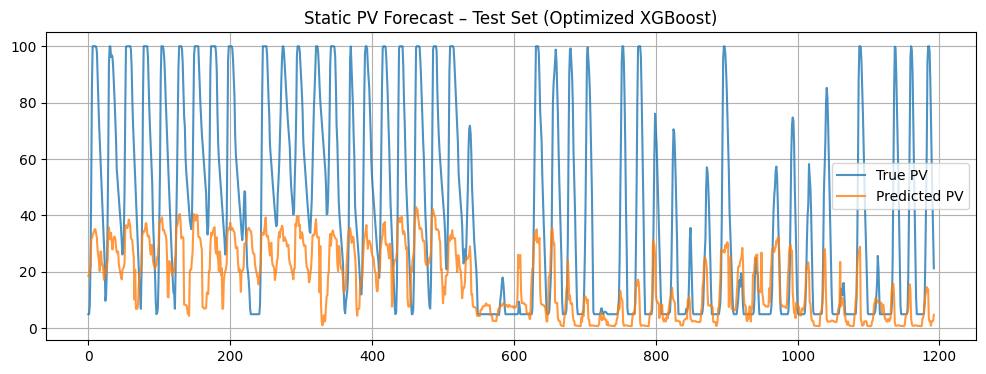

Next-step PV prediction: 4.779234104242945


In [8]:
best_params = study.best_params
best_params["objective"] = "reg:squarederror"
best_params["random_state"] = 42

model = xgb.XGBRegressor(**best_params)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Predictions
pred_val = model.predict(X_val)
pred_test = model.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("\nFinal Model Performance (Using Tuned Parameters):")
print("Validation RMSE:", rmse(y_val, pred_val))
print("Test RMSE:", rmse(y_test, pred_test))




 # INVERSE SCALE & PLOT


pred_test_inv = scaler_y.inverse_transform(pred_test.reshape(-1,1)).flatten()
y_test_inv    = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="True PV", alpha=0.8)
plt.plot(pred_test_inv, label="Predicted PV", alpha=0.8)
plt.legend()
plt.grid(True)
plt.title("Static PV Forecast – Test Set (Optimized XGBoost)")
plt.show()

# Next-step prediction
next_pred_scaled = model.predict(X_test.iloc[-1:])[0]
next_pred = scaler_y.inverse_transform([[next_pred_scaled]])[0][0]

print("Next-step PV prediction:", next_pred)